# CVAE - Laupheimer2024

# Etapa 3

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DB_PATH = "../db/tfm_vocs.db"
PARQUET_PATH = "../db/data/processed/abundancias_laupheimer2024.csv"

In [2]:
import pickle
import numpy as np
from pathlib import Path

MODELS_DIR = Path("../models")

def export_cvae(dataset_slug, encoder, decoder, iso_forest, autoencoder,
                 scores_loo, errores_loo_ae, scaler, compound_ids, meta=None):
    out = MODELS_DIR / dataset_slug
    out.mkdir(parents=True, exist_ok=True)
    encoder.save(out / "cvae_encoder.keras")
    decoder.save(out / "cvae_decoder.keras")
    autoencoder.save(out / "autoencoder.keras")

    with open(out / "isolation_forest.pkl", "wb") as f:
        pickle.dump(iso_forest, f)
    with open(out / "scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
    with open(out / "compound_ids.pkl", "wb") as f:
        pickle.dump(list(compound_ids), f)

    np.save(out / "scores_loo.npy", scores_loo)
    np.save(out / "errores_loo_ae.npy", errores_loo_ae)

    if meta:
        with open(out / "cvae_meta.pkl", "wb") as f:
            pickle.dump(meta, f)

    print(f"Exportado CVAE+detectores: {dataset_slug} -> {out}")

In [3]:
SEED = 42
tf.keras.utils.set_random_seed(SEED)

### Carga de datos

In [4]:
conn = sqlite3.connect(DB_PATH)

muestras = pd.read_sql(
    "SELECT sample_id, species, genotype, physiological_state, dataset_origin "
    "FROM muestras WHERE dataset_origin = 'Laupheimer2024'",
    conn
)
compuestos = pd.read_sql(
    "SELECT compuesto_id, name_original, pubchem_cid FROM compuestos WHERE dataset_origin = 'Laupheimer2024'",
    conn
)
conn.close()

voc = pd.read_csv(PARQUET_PATH)

print("Muestras:", muestras.shape)
print("Compuestos:", compuestos.shape)
print("Abundancias (formato largo):", voc.shape)
print("Nulos en abundancia:", voc["abundancia"].isnull().sum())
muestras.head()

Muestras: (32, 5)
Compuestos: (25, 3)
Abundancias (formato largo): (800, 4)
Nulos en abundancia: 378


,sample_id,species,genotype,physiological_state,dataset_origin
0,laupheimer2024_wt_control_1dai_r01,Hordeum vulgare,WT,control,Laupheimer2024
1,laupheimer2024_wt_control_1dai_r02,Hordeum vulgare,WT,control,Laupheimer2024
2,laupheimer2024_wt_control_1dai_r03,Hordeum vulgare,WT,control,Laupheimer2024
3,laupheimer2024_wt_control_1dai_r04,Hordeum vulgare,WT,control,Laupheimer2024
4,laupheimer2024_wt_infected_1dai_r05,Hordeum vulgare,WT,infected,Laupheimer2024


### Preprocesamiento

In [5]:
#Detección de contaminantes
pd.set_option("display.max_rows", 30)
compuestos[["compuesto_id", "name_original", "pubchem_cid"]]

,compuesto_id,name_original,pubchem_cid
0,laupheimer2024_cmp001,(Z)-3-Hexenol,5281167.0
1,laupheimer2024_cmp002,(Z)-3-Hexenyl acetate,5363388.0
2,laupheimer2024_cmp003,2-Ethyl hexanol,7720.0
3,laupheimer2024_cmp004,3-Heptanol,11520.0
4,laupheimer2024_cmp005,3-Heptanone,7802.0
5,laupheimer2024_cmp006,6-Methyl-5-heptenone,9862.0
6,laupheimer2024_cmp007,Heptane 2.3-dimethyl,26375.0
7,laupheimer2024_cmp008,Heptane 2.2.4.6.6-pentamethyl,26058.0
8,laupheimer2024_cmp009,Nonane,8141.0
9,laupheimer2024_cmp010,Nonanal,31289.0


In [6]:
# Pivot 
wide = voc.pivot(index="sample_id", columns="compuesto_id", values="abundancia")

# Imputar no detectados como 0 
print("Nulos antes de imputar:", wide.isnull().sum().sum())
wide = wide.fillna(0)
print("Nulos despues de imputar:", wide.isnull().sum().sum())

# Alinear con la metadata
muestras_idx = muestras.set_index("sample_id").loc[wide.index]

# log1p
X_log = np.log1p(wide.values)
y_labels = muestras_idx["physiological_state"].values

print("X_log:", X_log.shape)

Nulos antes de imputar: 378
Nulos despues de imputar: 0
X_log: (32, 25)


In [7]:
#Dividir tr/ts
idx_train, idx_val = train_test_split(
    np.arange(len(X_log)), test_size=0.2, random_state=42, stratify=y_labels
)

In [8]:
# Estandarizacion
scaler = StandardScaler()
X_train = scaler.fit_transform(X_log[idx_train]).astype("float32")
X_val = scaler.transform(X_log[idx_val]).astype("float32")

In [9]:
# Dummies para la var categórica
y_dummies = pd.get_dummies(pd.Series(y_labels, name="physiological_state"), drop_first=True)
print("Columna de condicionamiento:", y_dummies.columns.tolist())

y_train = y_dummies.iloc[idx_train].values.astype("float32")
y_val = y_dummies.iloc[idx_val].values.astype("float32")

print("X_train:", X_train.shape, " X_val:", X_val.shape)
print("y_train:", y_train.shape, " y_val:", y_val.shape)


Columna de condicionamiento: ['infected']
X_train: (25, 25)  X_val: (7, 25)
y_train: (25, 1)  y_val: (7, 1)


### Encoder

In [10]:
input_dim = X_train.shape[1]   
cond_dim = y_train.shape[1]
latent_dim = 2

x_in = layers.Input(shape=(input_dim,), name="x")
c_in = layers.Input(shape=(cond_dim,), name="condition")
h = layers.Concatenate()([x_in, c_in])
h = layers.Dense(16, activation="relu")(h)
h = layers.Dense(8, activation="relu")(h)

z_mean = layers.Dense(latent_dim, name="z_mean")(h)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(h)

def sampling(args):
    z_mean, z_log_var = args
    eps = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * eps

z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])

encoder = keras.Model([x_in, c_in], [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ x (InputLayer)                │ (None, 25)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ condition (InputLayer)        │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 26)                │               0 │ x[0][0], condition[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 16)                │             432 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 8)                 │             136 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_mean (Dense)                │ (None, 2)                 │              18 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_log_var (Dense)             │ (None, 2)                 │              18 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z (Lambda)                    │ (None, 2)                 │               0 │ z_mean[0][0],              │
│                               │                           │                 │ z_log_var[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 604 (2.36 KB)

 Trainable params: 604 (2.36 KB)

 Non-trainable params: 0 (0.00 B)

### Decoder

In [11]:
z_in = layers.Input(shape=(latent_dim,), name="z_sample")
c_in2 = layers.Input(shape=(cond_dim,), name="condition_dec")
h_dec = layers.Concatenate()([z_in, c_in2])
h_dec = layers.Dense(8, activation="relu")(h_dec)
h_dec = layers.Dense(16, activation="relu")(h_dec)
x_out = layers.Dense(input_dim, activation="linear")(h_dec)

decoder = keras.Model([z_in, c_in2], x_out, name="decoder")
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ z_sample (InputLayer)         │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ condition_dec (InputLayer)    │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 3)                 │               0 │ z_sample[0][0],            │
│                               │                           │                 │ condition_dec[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 8)                 │              32 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 16)                │             144 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 25)                │             425 │ dense_3[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 601 (2.35 KB)

 Trainable params: 601 (2.35 KB)

 Non-trainable params: 0 (0.00 B)

## CVAE

In [12]:
class CVAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = tf.Variable(0.0, trainable=False, dtype=tf.float32)
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        x, c = inputs
        _, _, z = self.encoder([x, c])
        return self.decoder([z, c])

    def _compute_losses(self, x, c):
        z_mean, z_log_var, z = self.encoder([x, c])
        x_recon = self.decoder([z, c])
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - x_recon), axis=1))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + self.beta * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        (x, c), _ = data
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(x, c)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        (x, c), _ = data
        total_loss, recon_loss, kl_loss = self._compute_losses(x, c)
        self.loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}


cvae = CVAE(encoder, decoder)


### Entrenamiento

In [13]:
class KLWarmup(keras.callbacks.Callback):
    def __init__(self, cvae, warmup_epochs=50, max_beta=1.0):
        super().__init__()
        self.cvae = cvae
        self.warmup_epochs = warmup_epochs
        self.max_beta = max_beta

    def on_epoch_begin(self, epoch, logs=None):
        new_beta = self.max_beta * min(1.0, epoch / self.warmup_epochs)
        self.cvae.beta.assign(new_beta)


cvae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
warmup_cb = KLWarmup(cvae, warmup_epochs=50, max_beta=1.0)

history = cvae.fit(
    x=(X_train, y_train), y=X_train,
    validation_data=((X_val, y_val), X_val),
    epochs=800, batch_size=8,
    callbacks=[warmup_cb], verbose=1
)

Epoch 1/800
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - kl_loss: 1.5980 - loss: 34.4964 - recon_loss: 34.4964 - val_kl_loss: 0.9925 - val_loss: 21.2245 - val_recon_loss: 21.2245
Epoch 2/800
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - kl_loss: 1.3593 - loss: 32.1296 - recon_loss: 32.1024 - val_kl_loss: 0.8572 - val_loss: 21.6136 - val_recon_loss: 21.5964
Epoch 3/800
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - kl_loss: 1.1761 - loss: 28.9326 - recon_loss: 28.8856 - val_kl_loss: 0.7463 - val_loss: 24.2889 - val_recon_loss: 24.2590
Epoch 4/800
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - kl_loss: 1.0288 - loss: 30.2249 - recon_loss: 30.1632 - val_kl_loss: 0.6545 - val_loss: 22.0679 - val_recon_loss: 22.0286
Epoch 5/800
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - kl_loss: 0.9164 - loss: 29.2223 - recon_loss: 29.1490 - val_kl_loss: 0.5881 - val_loss: 21.5283 - val_recon_loss: 21.4813
Epoch 6/800
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - kl_loss: 0.8316 - loss: 27.9575 - recon_loss: 27.8743 - val_kl_loss: 0.5408 - 

## Curva de pérdida

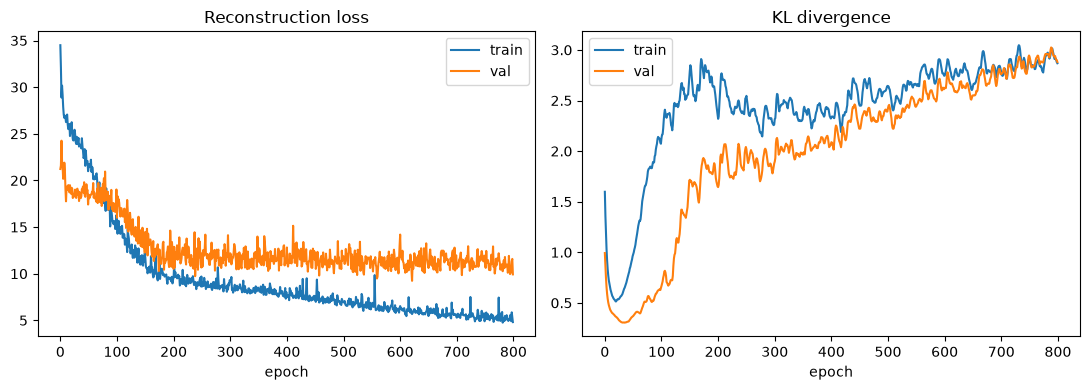

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["recon_loss"], label="train")
axes[0].plot(history.history["val_recon_loss"], label="val")
axes[0].set_title("Reconstruction loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history.history["kl_loss"], label="train")
axes[1].plot(history.history["val_kl_loss"], label="val")
axes[1].set_title("KL divergence")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

### Chequeo de reconstrucción

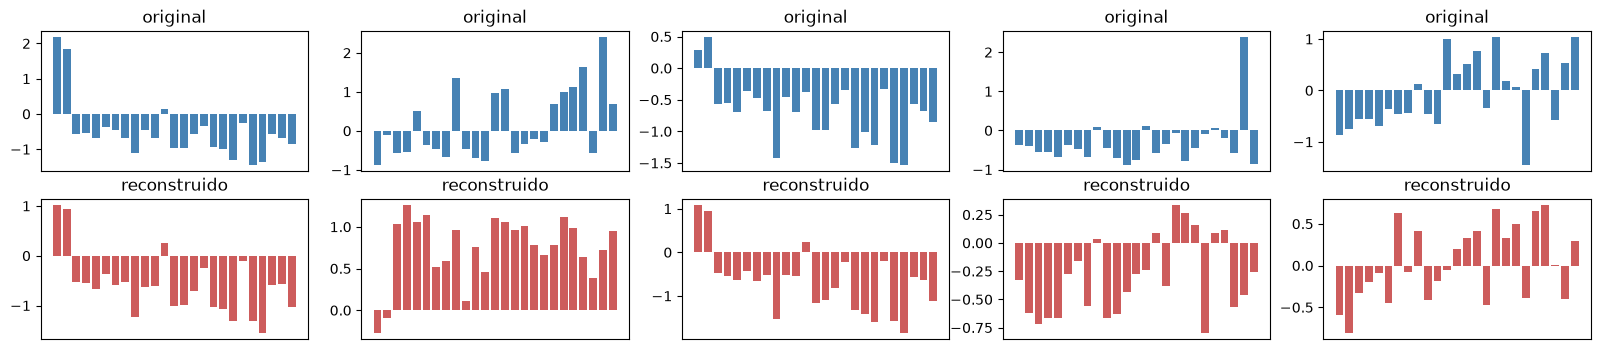

In [15]:
n = 5
x_sample = X_val[:n]
c_sample = y_val[:n]
x_recon = cvae((x_sample, c_sample)).numpy()

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.bar(range(X_val.shape[1]), x_sample[i], color="steelblue")
    plt.title("original")
    ax.get_xaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.bar(range(X_val.shape[1]), x_recon[i], color="indianred")
    plt.title("reconstruido")
    ax.get_xaxis().set_visible(False)
plt.show()

### Espacio altente

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


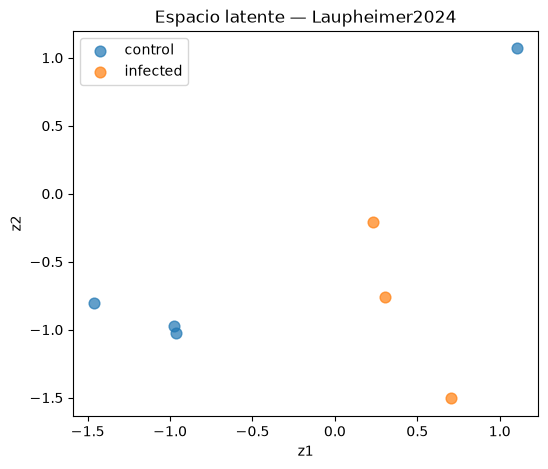

Silhouette score (validación): 0.2564951777458191


In [16]:
from sklearn.metrics import silhouette_score

z_mean_val, _, _ = encoder.predict([X_val, y_val])
labels_val = y_val[:, 0].astype(int)

plt.figure(figsize=(6, 5))
plt.scatter(z_mean_val[labels_val == 0, 0], z_mean_val[labels_val == 0, 1], label="control", alpha=0.7, s=60)
plt.scatter(z_mean_val[labels_val == 1, 0], z_mean_val[labels_val == 1, 1], label="infected", alpha=0.7, s=60)
plt.xlabel("z1")
plt.ylabel("z2")
plt.legend()
plt.title("Espacio latente — Laupheimer2024")
plt.show()

sil = silhouette_score(z_mean_val, labels_val)
print("Silhouette score (validación):", sil)

### Exploración de gradiente

In [17]:
z_fixed = np.zeros((1, latent_dim))

n_steps = 11
c_steps = np.linspace(0, 1, n_steps).reshape(-1, 1)
z_repeated = np.repeat(z_fixed, n_steps, axis=0)

perfiles_generados = decoder.predict([z_repeated, c_steps])

delta = perfiles_generados[-1] - perfiles_generados[0]

compound_ids = wide.columns
cambios = pd.DataFrame({"compuesto_id": compound_ids, "delta": delta})
cambios = cambios.merge(compuestos[["compuesto_id", "name_original", "pubchem_cid"]], on="compuesto_id", how="left")
cambios = cambios.reindex(cambios["delta"].abs().sort_values(ascending=False).index)

print("Top 10 compuestos que más cambian en el trayecto control a infected:")
cambios.head(10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Top 10 compuestos que más cambian en el trayecto control a infected:


,compuesto_id,delta,name_original,pubchem_cid
19,laupheimer2024_cmp020,-1.737059,Linalool,6549.0
11,laupheimer2024_cmp012,-1.272543,Decane-4-methyl,17835.0
21,laupheimer2024_cmp022,0.950756,(-)-Menthol,16666.0
13,laupheimer2024_cmp014,0.814303,n-Tetradecane,12389.0
20,laupheimer2024_cmp021,0.800749,Camphor,2537.0
18,laupheimer2024_cmp019,0.796417,1.8-Cineol,2758.0
7,laupheimer2024_cmp008,0.780774,Heptane 2.2.4.6.6-pentamethyl,26058.0
10,laupheimer2024_cmp011,0.719041,n-Decanal,8175.0
16,laupheimer2024_cmp017,0.601759,Camphene,6616.0
0,laupheimer2024_cmp001,0.501978,(Z)-3-Hexenol,5281167.0


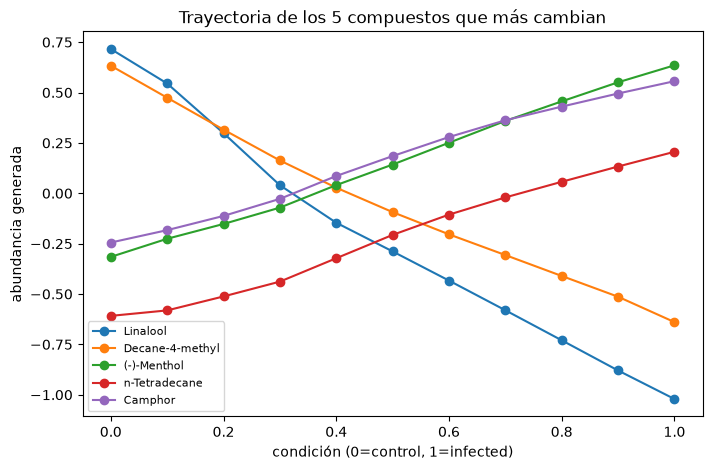

In [18]:
top5 = cambios.head(5)["compuesto_id"].tolist()
idx_top5 = [list(compound_ids).index(cid) for cid in top5]

plt.figure(figsize=(8, 5))
for i, cid in zip(idx_top5, top5):
    nombre = compuestos.loc[compuestos["compuesto_id"] == cid, "name_original"].values
    etiqueta = nombre[0] if len(nombre) else cid
    plt.plot(c_steps.flatten(), perfiles_generados[:, i], marker="o", label=etiqueta)

plt.xlabel("condición (0=control, 1=infected)")
plt.ylabel("abundancia generada")
plt.legend(fontsize=8)
plt.title("Trayectoria de los 5 compuestos que más cambian")
plt.show()

# Etapa 4

In [19]:
#Isolation forest
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import LeaveOneOut

X_real_cebada = np.vstack([X_train, X_val])
n_real_cebada = X_real_cebada.shape[0]
print(f"Muestras reales (cebada): {n_real_cebada}")

iso_final_cebada = IsolationForest(n_estimators=200, contamination="auto", random_state=SEED)
iso_final_cebada.fit(X_real_cebada)

score_generados_cebada = -iso_final_cebada.score_samples(perfiles_generados)

loo = LeaveOneOut()
scores_loo_cebada = np.zeros(n_real_cebada)
for train_idx, test_idx in loo.split(X_real_cebada):
    iso_fold = IsolationForest(n_estimators=200, contamination="auto", random_state=SEED)
    iso_fold.fit(X_real_cebada[train_idx])
    scores_loo_cebada[test_idx[0]] = -iso_fold.score_samples(X_real_cebada[test_idx])[0]

print("Distribución LOO If:")
print(pd.Series(scores_loo_cebada).describe())

Muestras reales (cebada): 32
Distribución LOO If:
count    32.000000
mean      0.480529
std       0.073168
min       0.394594
25%       0.421423
50%       0.463477
75%       0.516442
max       0.653835
dtype: float64


In [20]:
# % de la distrib de referncia queda debajo de score 
def percentil_vs_referencia(score, referencia):
    return (referencia < score).mean() * 100

percentiles_cebada = np.array([percentil_vs_referencia(s, scores_loo_cebada) for s in score_generados_cebada])

resultado_cebada = pd.DataFrame({
    "paso_condicion": c_steps.flatten(),
    "score_isolation_forest": score_generados_cebada,
    "percentil_if_vs_reales": percentiles_cebada,
})
resultado_cebada

,paso_condicion,score_isolation_forest,percentil_if_vs_reales
0,0.0,0.446870,40.625
1,0.1,0.438042,34.375
2,0.2,0.432588,34.375
3,0.3,0.421937,25.000
4,0.4,0.424681,31.250
5,0.5,0.426618,31.250
6,0.6,0.432490,34.375
7,0.7,0.435508,34.375
8,0.8,0.442204,37.500
9,0.9,0.447749,40.625


In [21]:
# Extrapolación para ver mas allá en una condición mayor a infected.
n_steps_extra = 11
c_steps_extra = np.linspace(1.0, 2.0, n_steps_extra).reshape(-1, 1)
z_repeated_extra = np.repeat(z_fixed, n_steps_extra, axis=0)

perfiles_extrapolados_cebada = decoder.predict([z_repeated_extra, c_steps_extra])

score_extrapolados_cebada = -iso_final_cebada.score_samples(perfiles_extrapolados_cebada)
percentiles_extrapolados_cebada = np.array(
    [percentil_vs_referencia(s, scores_loo_cebada) for s in score_extrapolados_cebada]
)

resultado_extrapolado_cebada = pd.DataFrame({
    "paso_condicion": c_steps_extra.flatten(),
    "score_isolation_forest": score_extrapolados_cebada,
    "percentil_if_vs_reales": percentiles_extrapolados_cebada,
})
resultado_extrapolado_cebada

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


,paso_condicion,score_isolation_forest,percentil_if_vs_reales
0,1.0,0.455170,40.625
1,1.1,0.458797,43.750
2,1.2,0.462440,50.000
3,1.3,0.468231,53.125
4,1.4,0.468095,53.125
5,1.5,0.471941,56.250
6,1.6,0.472309,56.250
7,1.7,0.471863,56.250
8,1.8,0.480539,56.250
9,1.9,0.485141,56.250


In [22]:
# Detector no condicional, independiente del CVAE
def build_autoencoder(input_dim, bottleneck=4):
    inputs = tf.keras.Input(shape=(input_dim,))
    encoded = layers.Dense(16, activation="relu")(inputs)
    encoded = layers.Dense(8, activation="relu")(encoded)
    encoded = layers.Dense(bottleneck, activation="relu")(encoded)
    decoded = layers.Dense(8, activation="relu")(encoded)
    decoded = layers.Dense(16, activation="relu")(decoded)
    decoded = layers.Dense(input_dim, activation="linear")(decoded)
    ae = tf.keras.Model(inputs, decoded)
    ae.compile(optimizer="adam", loss="mse")
    return ae

def recon_error(model, X):
    X_hat = model.predict(X, verbose=0)
    return np.mean((X - X_hat) ** 2, axis=1)

AE_EPOCHS = 150
AE_BATCH = 8

ae_final_cebada = build_autoencoder(X_real_cebada.shape[1])
ae_final_cebada.fit(X_real_cebada, X_real_cebada, epochs=AE_EPOCHS, batch_size=AE_BATCH, verbose=0)

loo = LeaveOneOut()
errores_loo_ae_cebada = np.zeros(n_real_cebada)
for train_idx, test_idx in loo.split(X_real_cebada):
    ae_fold = build_autoencoder(X_real_cebada.shape[1])
    ae_fold.fit(X_real_cebada[train_idx], X_real_cebada[train_idx], epochs=AE_EPOCHS, batch_size=AE_BATCH, verbose=0)
    errores_loo_ae_cebada[test_idx[0]] = recon_error(ae_fold, X_real_cebada[test_idx])[0]

print("Distribución LOO autoencoder :")
print(pd.Series(errores_loo_ae_cebada).describe())

Distribución LOO autoencoder :
count    32.000000
mean      0.544115
std       0.428250
min       0.019730
25%       0.117971
50%       0.466211
75%       0.770505
max       1.658818
dtype: float64


In [23]:
# Resúmen
error_generados_ae_cebada = recon_error(ae_final_cebada, perfiles_generados)
error_extrapolados_ae_cebada = recon_error(ae_final_cebada, perfiles_extrapolados_cebada)

resultado_cebada["percentil_ae_vs_reales"] = [
    percentil_vs_referencia(e, errores_loo_ae_cebada) for e in error_generados_ae_cebada
]
resultado_extrapolado_cebada["percentil_ae_vs_reales"] = [
    percentil_vs_referencia(e, errores_loo_ae_cebada) for e in error_extrapolados_ae_cebada
]

def clasificar(perc_if, perc_ae=None):
    percentiles = [p for p in [perc_if, perc_ae] if p is not None]
    if all(p > 97.5 for p in percentiles):
        return "novedoso"
    elif all(p < 90 for p in percentiles):
        return "plausible"
    else:
        return "frontera"

resultado_cebada["clasificacion"] = [
    clasificar(row.percentil_if_vs_reales, row.percentil_ae_vs_reales)
    for row in resultado_cebada.itertuples()
]
resultado_extrapolado_cebada["clasificacion"] = [
    clasificar(row.percentil_if_vs_reales, row.percentil_ae_vs_reales)
    for row in resultado_extrapolado_cebada.itertuples()
]

resultado_cebada

,paso_condicion,score_isolation_forest,percentil_if_vs_reales,percentil_ae_vs_reales,clasificacion
0,0.0,0.446870,40.625,28.125,plausible
1,0.1,0.438042,34.375,28.125,plausible
2,0.2,0.432588,34.375,25.000,plausible
3,0.3,0.421937,25.000,21.875,plausible
4,0.4,0.424681,31.250,18.750,plausible
5,0.5,0.426618,31.250,12.500,plausible
6,0.6,0.432490,34.375,12.500,plausible
7,0.7,0.435508,34.375,12.500,plausible
8,0.8,0.442204,37.500,12.500,plausible
9,0.9,0.447749,40.625,15.625,plausible


In [24]:
resultado_extrapolado_cebada

,paso_condicion,score_isolation_forest,percentil_if_vs_reales,percentil_ae_vs_reales,clasificacion
0,1.0,0.455170,40.625,18.750,plausible
1,1.1,0.458797,43.750,25.000,plausible
2,1.2,0.462440,50.000,28.125,plausible
3,1.3,0.468231,53.125,28.125,plausible
4,1.4,0.468095,53.125,28.125,plausible
5,1.5,0.471941,56.250,28.125,plausible
6,1.6,0.472309,56.250,28.125,plausible
7,1.7,0.471863,56.250,28.125,plausible
8,1.8,0.480539,56.250,28.125,plausible
9,1.9,0.485141,56.250,37.500,plausible


In [25]:
# Control + para corroborar
z_extremo_cebada = np.full((1, latent_dim), 5.0)
c_extremo_cebada = np.array([[1.0]])
perfil_control_positivo_cebada = decoder.predict([z_extremo_cebada, c_extremo_cebada])

score_if_control_cebada = -iso_final_cebada.score_samples(perfil_control_positivo_cebada)[0]
error_ae_control_cebada = recon_error(ae_final_cebada, perfil_control_positivo_cebada)[0]

print(f"  Score Isolation Forest: {score_if_control_cebada:.4f}  (percentil {percentil_vs_referencia(score_if_control_cebada, scores_loo_cebada):.1f}%)")
print(f"  Error autoencoder:      {error_ae_control_cebada:.4f}  (percentil {percentil_vs_referencia(error_ae_control_cebada, errores_loo_ae_cebada):.1f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
  Score Isolation Forest: 0.6569  (percentil 100.0%)
  Error autoencoder:      1.6327  (percentil 96.9%)


In [26]:
# Clasificación final - plausifle/frontera/novedoso

print("Gradiente observado (control a infected) - cebada:")
print(resultado_cebada[["paso_condicion", "clasificacion"]])
print("\nExtrapolación (infected a 2x infected) - cebada:")
print(resultado_extrapolado_cebada[["paso_condicion", "clasificacion"]])

Gradiente observado (control a infected) - cebada:
    paso_condicion clasificacion
0              0.0     plausible
1              0.1     plausible
2              0.2     plausible
3              0.3     plausible
4              0.4     plausible
5              0.5     plausible
6              0.6     plausible
7              0.7     plausible
8              0.8     plausible
9              0.9     plausible
10             1.0     plausible

Extrapolación (infected a 2x infected) - cebada:
    paso_condicion clasificacion
0              1.0     plausible
1              1.1     plausible
2              1.2     plausible
3              1.3     plausible
4              1.4     plausible
5              1.5     plausible
6              1.6     plausible
7              1.7     plausible
8              1.8     plausible
9              1.9     plausible
10             2.0     plausible


In [27]:
export_cvae(
    "laupheimer2024",
    encoder=encoder, decoder=decoder, iso_forest=iso_final_cebada, autoencoder=ae_final_cebada,
    scores_loo=scores_loo_cebada, errores_loo_ae=errores_loo_ae_cebada, scaler=scaler, compound_ids=compound_ids,
    meta={"especie": "Hordeum vulgare (Laupheimer 2024)"}
)

Exportado CVAE+detectores: laupheimer2024 -> ..\models\laupheimer2024
